In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === 1) Read JSON data ===
df_auction = pd.read_json("auc_tractors.json")
df_listings = pd.read_json("tractors175_combined.json")

# === 2) Clean and standardize Auction Data ===

# Convert 'price' to numeric
df_auction['price'] = (
    df_auction['price']
    .replace('[\$,]', '', regex=True)
    .replace('n/a', np.nan)
    .apply(pd.to_numeric, errors='coerce')
)

# Convert 'sold_date' to datetime
df_auction['sold_date'] = pd.to_datetime(df_auction['sold_date'], errors='coerce')

# Convert 'hours' to numeric
df_auction['hours'] = pd.to_numeric(
    df_auction['hours'].str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

# === 3) Clean and standardize Listing Data ===

# Convert 'price' to numeric
df_listings['price'] = (
    df_listings['price']
    .replace('[\$,]', '', regex=True)
    .replace('n/a', np.nan)
    .apply(pd.to_numeric, errors='coerce')
)

# Convert 'hours' to numeric (remove 'hours' suffix, commas, etc.)
df_listings['hours'] = df_listings['hours'].str.replace(' hours', '', regex=False)
df_listings['hours'] = pd.to_numeric(
    df_listings['hours'].str.replace(r'[^\d.]', '', regex=True),
    errors='coerce'
)

# Inspect top rows
print("Number of auction data scraped: %d"%len(df_auction))
print("Number of listing data scraped: %d"%len(df_listings))
print("Auction data sample:")
print(df_auction.head())
print("\nListing data sample:")
print(df_listings.head())


Number of auction data scraped: 62637
Number of listing data scraped: 9449
Auction data sample:
   page_number                   name     price  sold_date  category  \
0            1  1997 New Holland 9482   60000.0 2025-03-22  Tractors   
1            1  2017 John Deere 8320R  183500.0 2025-03-22  Tractors   
2            1   2001 John Deere 8210  132500.0 2025-03-22  Tractors   
3            1   1995 John Deere 8200   79000.0 2025-03-22  Tractors   
4            1           Case IH DX33    5800.0 2025-03-22  Tractors   

   condition   hours auction_type  
0  Excellent  4714.0         Farm  
1  Excellent  3552.0         Farm  
2  Excellent  3059.0         Farm  
3  Excellent  4305.0         Farm  
4       Good   958.0         Farm  

Listing data sample:
    item_id                item_name       brand     price   hours   HP  \
0  21527516   2021 John Deere 9620RX  John Deere  364510.0  4049.0  620   
1  21588853   2022 John Deere 8R 370  John Deere  327800.0  2527.0  370   
2  21710

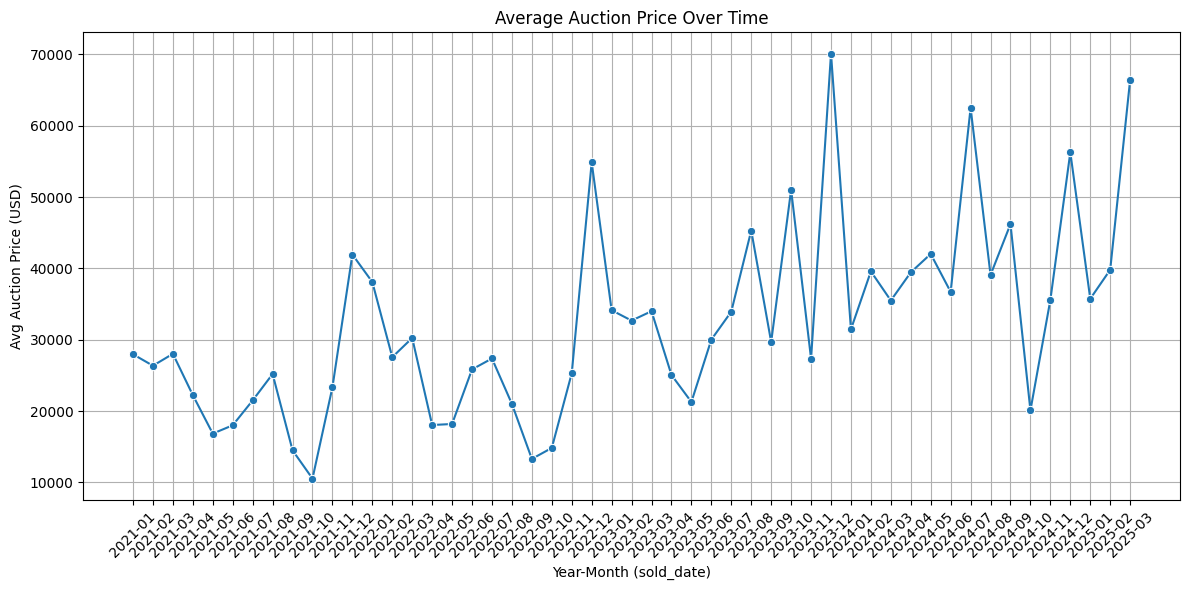

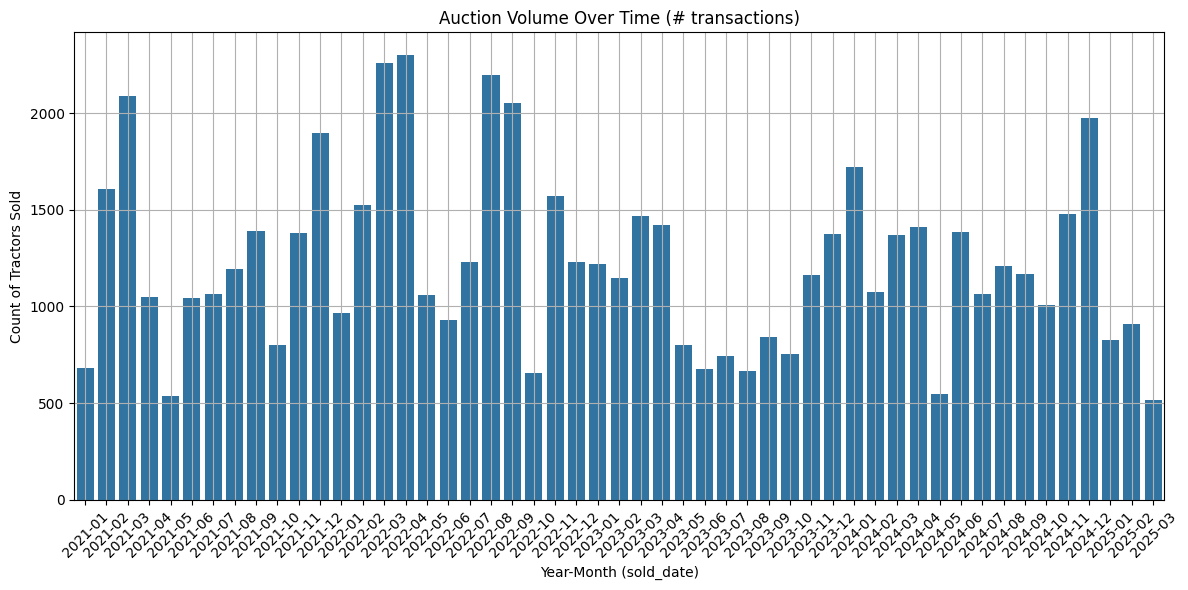

In [2]:
# Auction Price Over Time
df_auction['year_month'] = df_auction['sold_date'].dt.to_period('M')
auction_monthly = df_auction.groupby('year_month', dropna=True)['price'].agg(['mean','count']).reset_index()

# Convert Period to string for plotting
auction_monthly['year_month_str'] = auction_monthly['year_month'].astype(str)

# Plot Auction Price Over Time
plt.figure(figsize=(12,6))
sns.lineplot(data=auction_monthly, x='year_month_str', y='mean', marker='o')
plt.title('Average Auction Price Over Time')
plt.xlabel('Year-Month (sold_date)')
plt.ylabel('Avg Auction Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Auction Volume Over Time
plt.figure(figsize=(12,6))
sns.barplot(data=auction_monthly, x='year_month_str', y='count')
plt.title('Auction Volume Over Time (# transactions)')
plt.xlabel('Year-Month (sold_date)')
plt.ylabel('Count of Tractors Sold')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

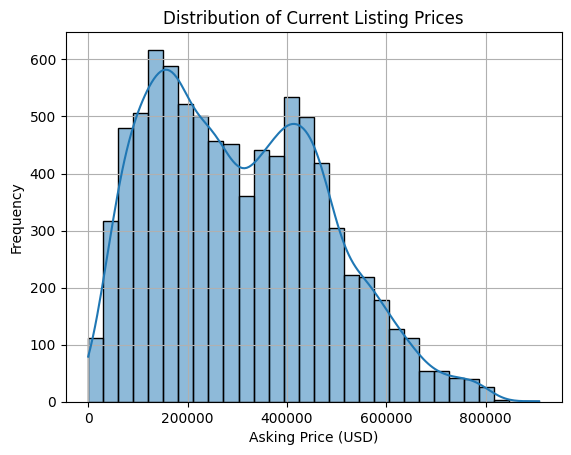

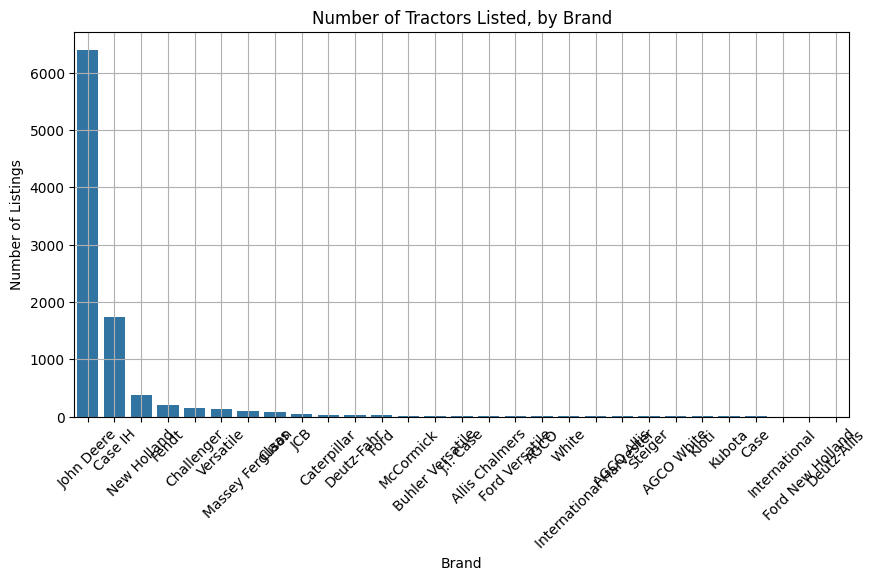

In [5]:
# Distribution of listing prices
sns.histplot(df_listings['price'], bins=30, kde=True)
plt.title('Distribution of Current Listing Prices')
plt.xlabel('Asking Price (USD)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Listing Volume by Brand
listings_by_brand = df_listings['brand'].value_counts().reset_index()
listings_by_brand.columns = ['brand','count']

plt.figure(figsize=(10,5))
sns.barplot(data=listings_by_brand, x='brand', y='count')
plt.title('Number of Tractors Listed, by Brand')
plt.xlabel('Brand')
plt.ylabel('Number of Listings')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


In [6]:
df_auction_deere = df_auction[df_auction['name'].str.contains('John Deere', case=False, na=False)]
df_listings_deere = df_listings[df_listings['brand'].str.contains('John Deere', case=False, na=False)]

print("Average Auction Price for Deere:", df_auction_deere['price'].mean())
print("Average Listing Price for Deere:", df_listings_deere['price'].mean())

print("Volume of Deere in Auction data:", len(df_auction_deere))
print("Volume of Deere in Listing data:", len(df_listings_deere))


Average Auction Price for Deere: 47375.875
Average Listing Price for Deere: 334069.52647823264
Volume of Deere in Auction data: 26874
Volume of Deere in Listing data: 6394


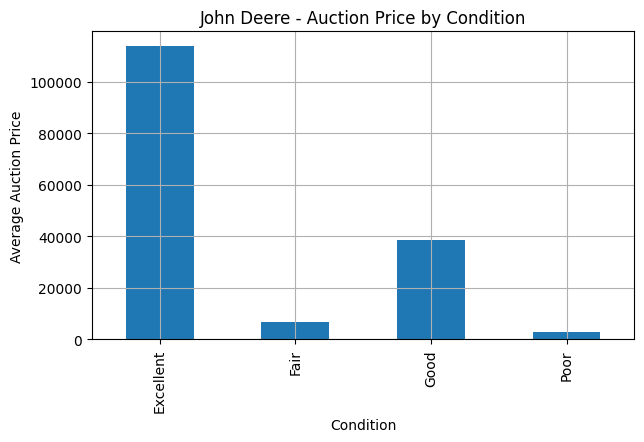

In [7]:
df_auction_deere.groupby('condition')['price'].mean().plot(kind='bar', figsize=(7,4))
plt.title("John Deere - Auction Price by Condition")
plt.xlabel("Condition")
plt.ylabel("Average Auction Price")
plt.grid(True)
plt.show()

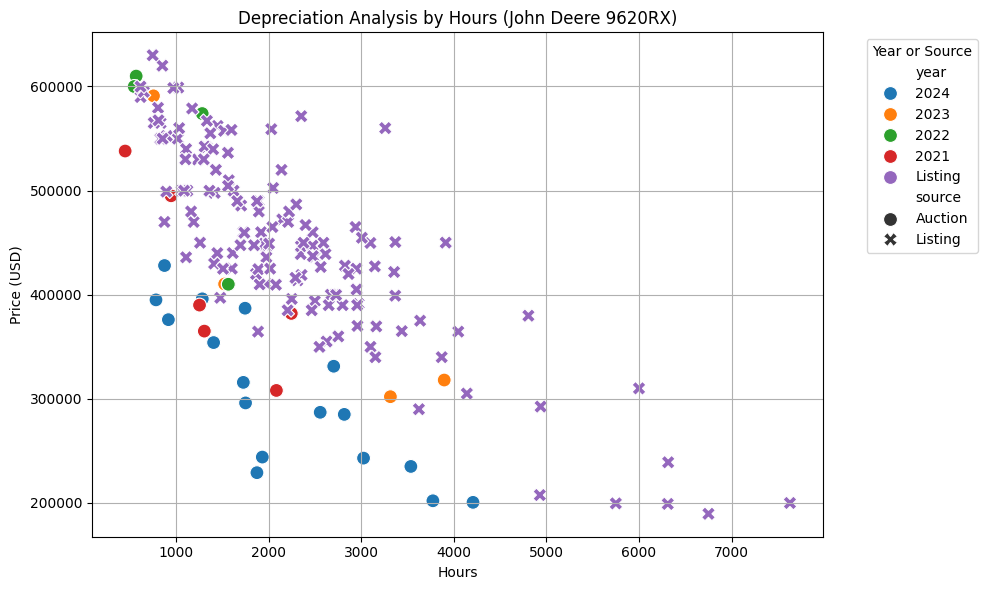

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Filter Auction Data for John Deere 9620RX
df_jd_auct = df_auction[
    df_auction['name'].str.contains('John Deere', case=False, na=False) &
    df_auction['name'].str.contains('9620RX', case=False, na=False)
].copy()

# 2) Filter Listing Data for John Deere 9620RX
df_jd_list = df_listings[
    df_listings['item_name'].str.contains('John Deere', case=False, na=False) &
    df_listings['item_name'].str.contains('9620RX', case=False, na=False)
].copy()

# 3) Extract the year from sold_date (auction data)
df_jd_auct['year'] = df_jd_auct['sold_date'].dt.year

# 4) For listing data, just set year = "Listing"
df_jd_list['year'] = "Listing"

# 5) Add an indicator column for source
df_jd_auct['source'] = "Auction"
df_jd_list['source'] = "Listing"

# 6) Subset relevant columns and merge
df_jd_auct_sub = df_jd_auct[['price', 'hours', 'year', 'source']]
df_jd_list_sub = df_jd_list[['price', 'hours', 'year', 'source']]

df_9620rx_combined = pd.concat([df_jd_auct_sub, df_jd_list_sub], ignore_index=True)

# 7) Scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_9620rx_combined,
    x='hours',
    y='price',
    hue='year',         # color-coded by year (or "Listing")
    style='source',     # optionally vary marker by Auction vs. Listing
    palette='tab10',    # choose a color palette
    s=100               # marker size
)

plt.title("Depreciation Analysis by Hours (John Deere 9620RX)")
plt.xlabel("Hours")
plt.ylabel("Price (USD)")
plt.grid(True)
plt.legend(title='Year or Source', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


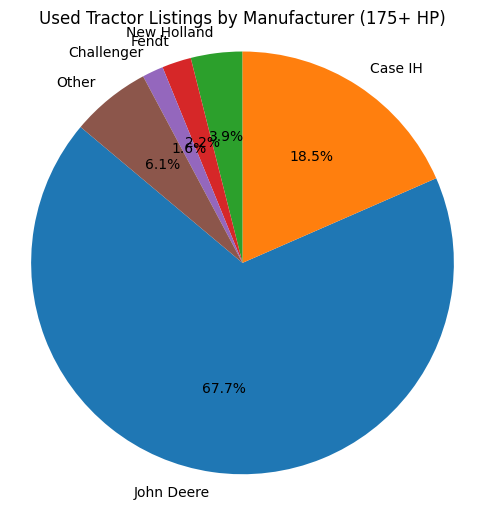

In [10]:
# 1. Count how many listings per brand
brand_counts = df_listings['brand'].value_counts(dropna=True)

# 2. Optionally, combine smaller brands into "Other" if desired
top_n = 5
top_brands = brand_counts.head(top_n)
others = brand_counts[top_n:].sum()  # sum the rest
top_brands['Other'] = others

# 3. Plot a pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    top_brands.values,
    labels=top_brands.index,
    autopct='%.1f%%',
    startangle=140
)
plt.title("Used Tractor Listings by Manufacturer (175+ HP)")
plt.axis('equal')  # makes the pie chart circular
plt.show()


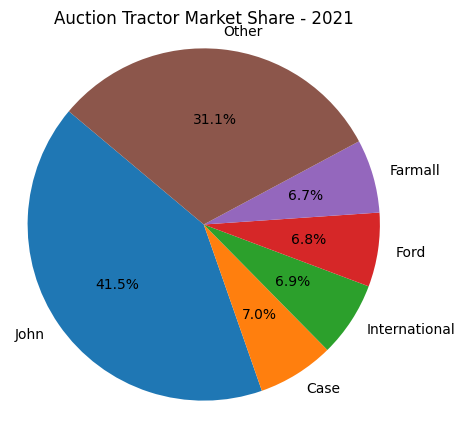

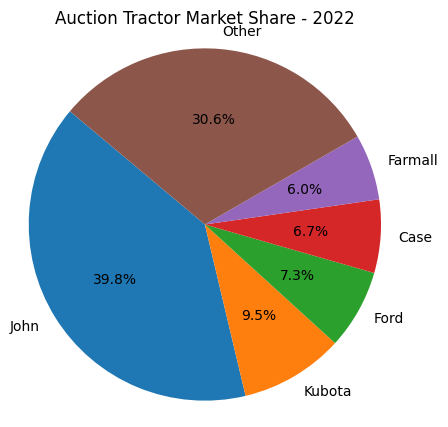

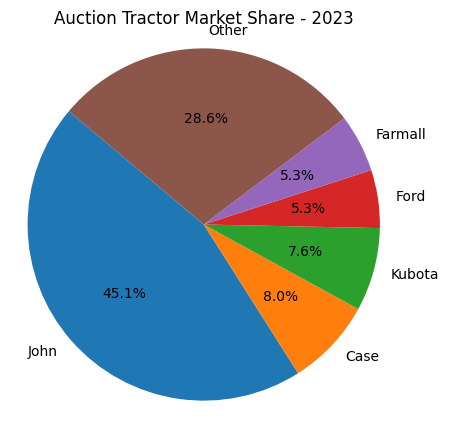

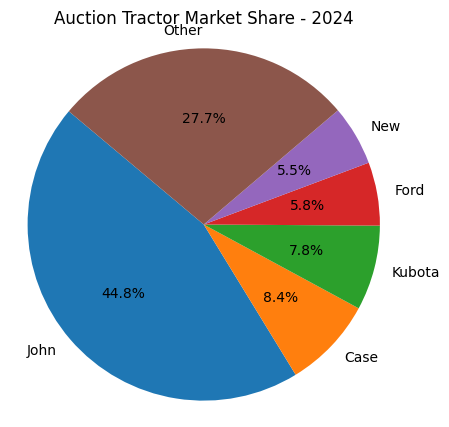

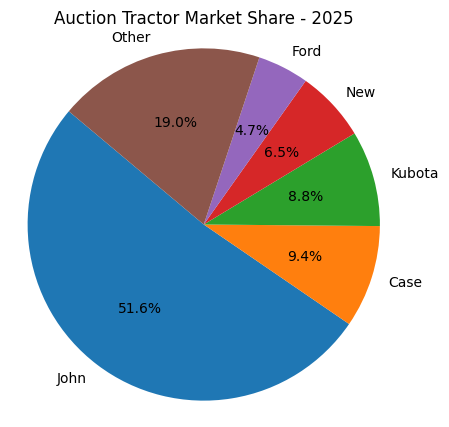

In [11]:
df_auction['year'] = df_auction['sold_date'].dt.year  # extract just the year

# For each distinct sold_date year, plot a separate pie chart
years = df_auction['year'].dropna().unique()
years = sorted(years)

for y in years:
    subset = df_auction[df_auction['year'] == y]
    brand_counts_auction = subset['name'].str.extract(r'^(?:\d{4}\s+)?(\S+)', expand=False)
    # Explanation above: We often do something like parse out the first word from `name`,
    # to treat it as the “brand” (if your raw data doesn't explicitly have a brand column).
    # If df_auction already has a brand column, just use that directly:
    # brand_counts_auction = subset['brand']  

    brand_counts_auction = brand_counts_auction.value_counts()
    
    top_n = 5
    top_brands_auction = brand_counts_auction.head(top_n)
    others_auction = brand_counts_auction[top_n:].sum()
    top_brands_auction['Other'] = others_auction

    plt.figure(figsize=(5,5))
    plt.pie(
        top_brands_auction.values,
        labels=top_brands_auction.index,
        autopct='%.1f%%',
        startangle=140
    )
    plt.title(f"Auction Tractor Market Share - {int(y)}")
    plt.axis('equal')
    plt.show()


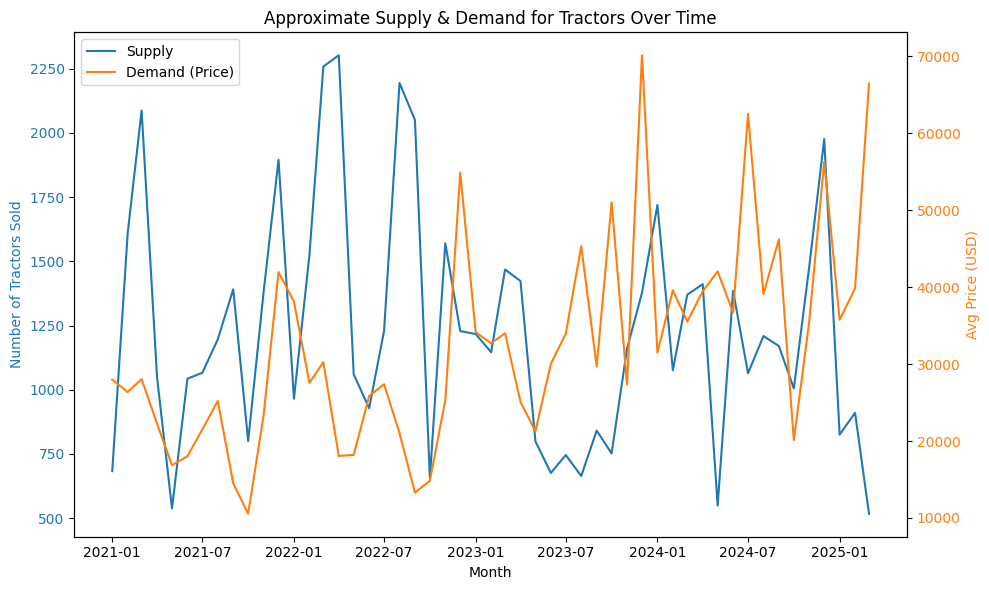

In [15]:
import json

# Load the JSON data
with open("auc_tractors.json", "r") as f:
    data = json.load(f)

df = pd.DataFrame(data)

# Filter to keep only tractors
df_tractors = df[df['category'].str.lower() == 'tractors']

# Clean and convert the price column to numeric
df_tractors['price'] = (
    df_tractors['price']
    .replace('n/a', '', regex=False)
    .str.replace(r'[\$,]', '', regex=True)
    .replace('', pd.NA)
)
df_tractors['price'] = pd.to_numeric(df_tractors['price'], errors='coerce')

# Drop rows with missing prices
df_tractors = df_tractors.dropna(subset=['price'])

# Convert sold_date to datetime, then extract the month
df_tractors['sold_date'] = pd.to_datetime(df_tractors['sold_date'], errors='coerce')
df_tractors['month'] = df_tractors['sold_date'].dt.to_period('M').dt.to_timestamp()

# Group by month: supply (# of tractors sold) and average price (demand proxy)
monthly_stats = (
    df_tractors.groupby('month')
    .agg(
        supply=('price', 'count'),
        avg_price=('price', 'mean')
    )
    .reset_index()
)

# Plot with two y-axes
fig, ax1 = plt.subplots(figsize=(10, 6))

# Convert pandas Series to numpy arrays explicitly
months = monthly_stats['month'].to_numpy()
supply = monthly_stats['supply'].to_numpy()
avg_price = monthly_stats['avg_price'].to_numpy()

# Plot supply (left axis)
color_supply = 'tab:blue'
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Tractors Sold', color=color_supply)
ax1.plot(months, supply, color=color_supply, label='Supply')
ax1.tick_params(axis='y', labelcolor=color_supply)

# Create a second y-axis for demand (price)
ax2 = ax1.twinx()
color_demand = 'tab:orange'
ax2.set_ylabel('Avg Price (USD)', color=color_demand)
ax2.plot(months, avg_price, color=color_demand, label='Demand (Price)')
ax2.tick_params(axis='y', labelcolor=color_demand)

# Combine legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Title and layout
plt.title("Approximate Supply & Demand for Tractors Over Time")
plt.tight_layout()
plt.show()

/var/folders/jv/5qhshsj137j5sb8t32sxd5x00000gn/T/ipykernel_82305/271871755.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df.rename(columns={
/Users/xianghe/opt/anaconda3/envs/crawl/lib/python3.9/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


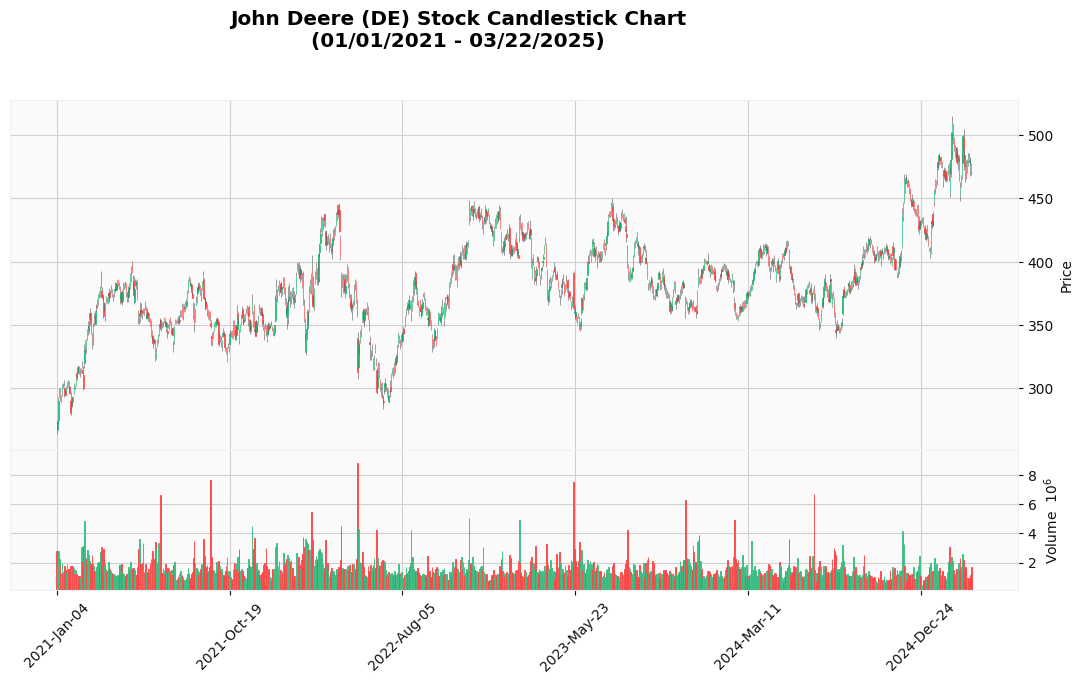

In [16]:
import akshare as ak
import mplfinance as mpf

stock_de_daily_df = ak.stock_us_daily(symbol="DE")

# Convert 'date' to datetime format and set as index
stock_de_daily_df['date'] = pd.to_datetime(stock_de_daily_df['date'])
stock_de_daily_df.set_index('date', inplace=True)

# Filter data for the desired date range
filtered_df = stock_de_daily_df.loc['2021-01-01':'2025-03-22']

# Ensure the column names are compatible
filtered_df.rename(columns={
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'close': 'Close',
    'volume': 'Volume'
}, inplace=True)

# Plotting candlestick chart
mpf.plot(
    filtered_df,
    type='candle',
    volume=True,
    title="John Deere (DE) Stock Candlestick Chart\n(01/01/2021 - 03/22/2025)",
    style='yahoo',
    figsize=(14,7)
)


In [17]:
import asyncio
import random
from urllib.parse import urlencode
from crawl4ai import AsyncWebCrawler, BrowserConfig, CrawlerRunConfig
from bs4 import BeautifulSoup
from langchain_openai import OpenAIEmbeddings, OpenAI
from langchain_community.vectorstores import Chroma
from langchain.chains import RetrievalQA
from dotenv import load_dotenv
import os
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import AzureChatOpenAI

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
SCRAPEOPS_API_KEY = os.getenv("SCRAPEOPS_API_KEY")
SCRAPEOPS_PROXY_URL = "https://proxy.scrapeops.io/v1/"

def build_scrapeops_proxied_url(target_url, bypass="generic_level_2"):
    params = {"api_key": SCRAPEOPS_API_KEY, "url": target_url, "bypass": bypass}
    return f"{SCRAPEOPS_PROXY_URL}?{urlencode(params)}"

async def scrape_equipment(equipment_type, max_pages=3):
    start_url = f"https://www.machinerypete.com/custom-search?custom_search={equipment_type}"
    browser_config = BrowserConfig(headless=True)
    listings_data = []

    async with AsyncWebCrawler(config=browser_config) as crawler:
        current_page, current_url = 1, start_url
        while current_url and current_page <= max_pages:
            proxied_url = build_scrapeops_proxied_url(current_url)
            run_config = CrawlerRunConfig(
                magic=False, delay_before_return_html=5.0,
                wait_for="div.listing-wrapper"
            )
            result = await crawler.arun(url=proxied_url, config=run_config)
            soup = BeautifulSoup(result.html, 'html.parser')

            listings = soup.select('div.listing-wrapper')
            for listing in listings:
                name = listing.select_one('div.listing-name h3').get_text(strip=True) if listing.select_one('div.listing-name h3') else None
                price = listing.select_one('div.listing-price').get_text(strip=True) if listing.select_one('div.listing-price') else None
                location = listing.select_one('div.listing-location').get_text(strip=True) if listing.select_one('div.listing-location') else None
                
                listings_data.append(f"{name} priced at {price}, located at {location}")

            next_page_tag = soup.select_one('ul.pagination li a[rel="next"]')
            if next_page_tag:
                current_url = "https://www.machinerypete.com" + next_page_tag.get('href')
                current_page += 1
            else:
                break
            await asyncio.sleep(random.randint(2, 4))
    return listings_data

async def create_rag_from_scraped_data(documents):
    embeddings = OpenAIEmbeddings(api_key=OPENAI_API_KEY)
    vectorstore = Chroma.from_texts(documents, embeddings)
    qa_chain = RetrievalQA.from_chain_type(
        llm=OpenAI(api_key=OPENAI_API_KEY),
        retriever=vectorstore.as_retriever()
    )
    return qa_chain

async def answer_user_query(equipment_type, user_query):
    scraped_data = await scrape_equipment(equipment_type)
    qa_chain = await create_rag_from_scraped_data(scraped_data)
    answer = qa_chain.invoke(user_query)
    return answer

async def main():
    equipment_type = "tractors"
    user_query = "What's the typical price range for John Deere %s?"%equipment_type
    print(user_query)
    print(f"Scraping MachineryPete for '{equipment_type}' and answering the query...\n")
    answer = await answer_user_query(equipment_type, user_query)
    print("LLM-generated Answer:")
    print(answer)

await main()

What's the typical price range for John Deere tractors?
Scraping MachineryPete for 'tractors' and answering the query...

[INIT].... → Crawl4AI 0.5.0.post4
[FETCH]... ↓ https://proxy.scrapeops.io/v1/?api_key=d3a8449c-db... | Status: True | Time: 16.85s
[SCRAPE].. ◆ https://proxy.scrapeops.io/v1/?api_key=d3a8449c-db... | Time: 0.495s
[COMPLETE] ● https://proxy.scrapeops.io/v1/?api_key=d3a8449c-db... | Status: True | Total: 17.36s
[FETCH]... ↓ https://proxy.scrapeops.io/v1/?api_key=d3a8449c-db... | Status: True | Time: 14.96s
[SCRAPE].. ◆ https://proxy.scrapeops.io/v1/?api_key=d3a8449c-db... | Time: 0.474s
[COMPLETE] ● https://proxy.scrapeops.io/v1/?api_key=d3a8449c-db... | Status: True | Total: 15.46s
[FETCH]... ↓ https://proxy.scrapeops.io/v1/?api_key=d3a8449c-db... | Status: True | Time: 15.52s
[SCRAPE].. ◆ https://proxy.scrapeops.io/v1/?api_key=d3a8449c-db... | Time: 0.447s
[COMPLETE] ● https://proxy.scrapeops.io/v1/?api_key=d3a8449c-db... | Status: True | Total: 15.98s
LLM-generated

# Summary Report

I conducted an in-depth analysis of the used agricultural tractor market, leveraging data scraped from MachineryPete.com, encompassing auction results (Jan 2021 - Mar 2025) and current dealer/private listings (focus on 175+ HP tractors). The analysis utilizes Python for data processing and visualization to identify market dynamics, derive implications for key publicly traded OEMs (Deere & Company, CNH Industrial, AGCO Corporation), and recommend further diligence.

The used tractor market, as viewed through Machinery Pete data, exhibits significant dynamism and segmentation. Average auction prices, while highly volatile and substantially elevated compared to early 2021 levels, experienced a sharp pullback in March 2025, coinciding with low auction volume. This recent softness follows peak average prices observed in February 2025. The current listing market for higher horsepower tractors (175+HP) is characterized by high asking prices and is overwhelmingly dominated by John Deere (67.7% share). A detailed analysis of the John Deere 9620RX model confirms expected depreciation trends based on hours and indicates listing asking prices generally sit at or slightly above recent auction realizations for comparable units. The broader auction market shows a different brand mix than high-HP listings, with John Deere still leading (~40-45% share historically, rising to ~51.6% in Q1 2025).

Key takeaways for public companies center on the confirmation of John Deere's strong brand equity and resale value, supported by its leading share in both listings and auctions, significant price premiums for equipment in excellent condition, strong value retention for high-value models, and recent gains in auction market share. CNH Industrial holds a solid second position in high-HP listings but appears to have a smaller share in the broader auction market. AGCO has a relatively smaller footprint in both datasets analyzed. The observed market volatility and recent auction market cooling suggest sensitivity to macroeconomic factors and potential emerging uncertainty. Further diligence should prioritize like-for-like model comparisons across brands, improved data parsing, segment analysis within auction data, external data validation, and macroeconomic correlation.

1. Introduction:

This analysis utilized proprietary scraped data from MachineryPete.com, focusing on agricultural tractors. Two primary datasets formed the basis of this study:

Auction Data (auc_tractors.json): Containing verified sale prices, sold_date (spanning January 2021 to March 2025), hours, condition, and descriptive information for tractors sold at auction across various types and sizes.

Listing Data (tractors175_combined.json): Containing current asking prices, hours, horsepower (HP), brand, specifications (specs), and seller information for tractors listed for sale, with data focused on units with 175 HP or more.

Based on these data, I perform data loading, cleaning, and standardization using Python (pandas). 
Key steps included converting price and hours to numeric types, parsing dates, and handling missing values.
Time-series analysis of monthly auction volume and average prices.
Cross-sectional analysis of price drivers (Age, Hours, HP, Brand, Condition).
Brand market share calculation for both listings and auctions (yearly for auctions).
Comparative analysis between auction realization values and listing asking prices, including a specific deep-dive into the John Deere 9620RX model.
Visualization of trends and distributions using matplotlib and seaborn.
Technical analysis using John Deere (DE) stock price trends (via akshare and mplfinance).

2. Market Dynamics Analysis:

Auction Price Levels & Time Series: Average auction prices exhibited significant month-to-month volatility between Jan 2021 and Mar 2025. While generally remaining substantially elevated compared to early 2021, prices saw multiple peaks, with the top on late 2023. This high volatility suggests sensitivity to market conditions and equipment mix. (See Plot: Average Auction Price Over Time).

Listing Price Levels: The current listing dataset (175HP+ focus) shows high asking prices, with a bimodal distribution suggesting value clusters (two peaks at 150k and 400k). The average asking price for listed John Deere units was much higher than the average auction price, primarily reflecting the different nature of equipment in the two datasets. (See Plot: Distribution of Current Listing Prices).

Price Drivers (Hours, Condition): Price demonstrates a clear negative correlation with machine hours, as explicitly shown in the depreciation analysis for the John Deere 9620RX. (See Plot: Depreciation Analysis by Hours - John Deere 9620RX). Seller-reported condition is also a critical factor, particularly at auction. 'Excellent' condition John Deere units have an average price nearly three times that of 'Good' condition units. (See Plot: John Deere - Auction Price by Condition).

Yearly Auction Trends and Listing Spread: The scatter plot for John Deere 9620RX model from 2021 to 2025 reveals some interesting things. Due to the pandemic, auction price peaked at 2022 with very little supply (Green Spot). On 2024, there are much more supply and the auction price dropped significantly (Blue Spot). The listing prices for John Deere 9620RX model are generally sit at or somewhat above recent auction realization prices for units with comparable hours (Purple Cross). This suggests seller asking prices are anchored towards the higher end compare to actual deal making price. (See Plot: Depreciation Analysis by Hours - John Deere 9620RX).

Supply-Demand Correlation: There is a weak inverse correlation between monthly auction volume and average price. Periods of high supply often coincided with lower average prices. Conversely, when supply was constrained, prices generally increased, reflecting typical market dynamics. The recent sharp drop on supply and rise on demand in 2025 is a potentially concerning signal. (See Plot: Approximate Supply & Demand for Tractors Over Time).

Listing Inventory Composition (175+HP): This segment on Machinery Pete is heavily concentrated, with John Deere representing 67.7% of listings. CNH Industrial (Case IH + New Holland) accounts for 22.4%, and AGCO brands make up a smaller share (4-6%). (See Pie Chart: Used Tractor Listings by Manufacturer).

Auction Supply Mix: The broader auction market reflects a different composition. While John Deere still leads in volume share (40-45% in 2021-2024, increasing to 51.6% in Q1 2025), there is a significant presence of other brands (Ford, International) and utility-focused brands (Kubota). Case IH/Case appears to have a smaller share (7-9%) in auctions compared to high-HP listings. This underscores that the auction market encompasses a much wider range of tractor ages, sizes, and types. (See Pie Charts: Auction Tractor Market Share by Year).

Brand Dynamics: John Deere holds a dominant position in the high-HP listing market analyzed and a leading, recently increasing, share in the broader auction market. Its equipment demonstrates strong value retention linked to condition and model type (e.g., 9620RX).
CNH Industrial is the clear number two in high-HP listings but appears less dominant in the overall auction volumes captured.
AGCO brands have a smaller representation in both datasets analyzed.

3. Key Takeaways for Public Companies (Deere, CNH, AGCO):

John Deere (DE):
The analysis strongly validates Deere's premium brand positioning and robust resale value – key supports for new equipment pricing power. This is evidenced by dominant listing share, leading auction share, high prices for 'Excellent' condition units, strong value retention of flagship models (9620RX), and a notable increase in auction share in early 2025.
Deere's stock price reached new highs in early 2025, suggesting strong investor confidence. Its resilience in March 2025, despite the market correction, indicates the stock reflects broader corporate performance and outlook beyond immediate used auction trends. (See Plot: John Deere (DE) Stock Candlestick Chart).

CNH Industrial (CNHI):
CNH holds a solid second position in the crucial high-HP listing segment (22% share).
Its smaller apparent share in the broader auction data (7-9% for Case IH/Case, 4-5% for New Holland) warrants further investigation, potentially through segment-specific analysis within auction data, to understand if this reflects overall volume or specific segment strengths/weaknesses.

AGCO Corporation (AGCO):
AGCO brands (Fendt, Massey Ferguson, Challenger, etc.) collectively hold a smaller share in both the high-HP listings (4-6%) and the overall auction volumes analyzed here. Their strength may lie in specific niches or geographies not fully captured or isolated in this dataset.

Overall, periods of higher auction volumes and declining tractor prices appear to coincide with heightened stock volatility and price corrections. This suggests that secondary market dynamics for equipment may act as early signals or proxies for investor sentiment towards industrial and agricultural equipment manufacturers.

4. Spider + RAG + LLM:

Here I am showing a simple example of combining scraping, embedding-based retrieval, and LLM generation to provide an interactive, data-driven Q&A system over newly collected market data. For Longaeva, it means quick insights on equipment listings in a more automated, intelligent way.

5. Next Steps & Further Diligence:

Expand the specific model deep-dive analysis (similar to the 9620RX plot) to other key models across competitors (e.g., Deere 8R vs. Case IH Magnum vs. Fendt 900/1000 Vario) to compare depreciation curves and auction/listing price spreads accurately.
Segment Analysis: Analyze auction data trends specifically within defined HP ranges and age brackets to allow for better comparison with listing data and understand segment-specific dynamics.
External Data Validation: Cross-reference findings with data from other major auction houses (Ritchie Bros., BigIron), data aggregators (Sandhills Global), and OEM financial reports.
Macroeconomic Correlation: Develop models to quantitatively assess the relationship between used equipment price indices (derived from scraped data) and key macro factors (crop prices, USDA Net Farm Income, Fed Funds Rate, relevant PPIs) and OEM stock performance.

6. Conclusion:

This Python-driven analysis of Machinery Pete data provides valuable, granular insights into the used agricultural tractor market. The market exhibits distinct dynamics across different segments, with John Deere demonstrating significant strength in both high-horsepower listings and overall auction volumes. While the market has shown resilience and high price levels compared to historical norms, recent volatility on auction metrics in 2025 warrant close monitoring. For Longaeva, understanding the nuances between market segments, performing detailed competitive analysis, and correlating findings with broader economic indicators will be critical for making informed investment decisions regarding Deere, CNH Industrial, and AGCO.

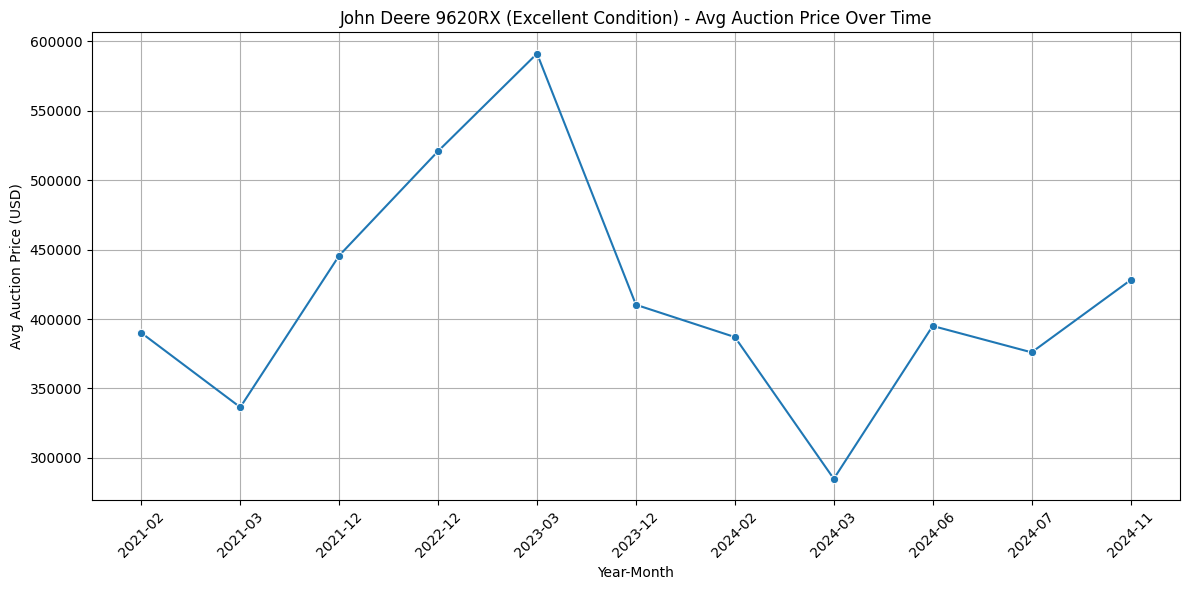

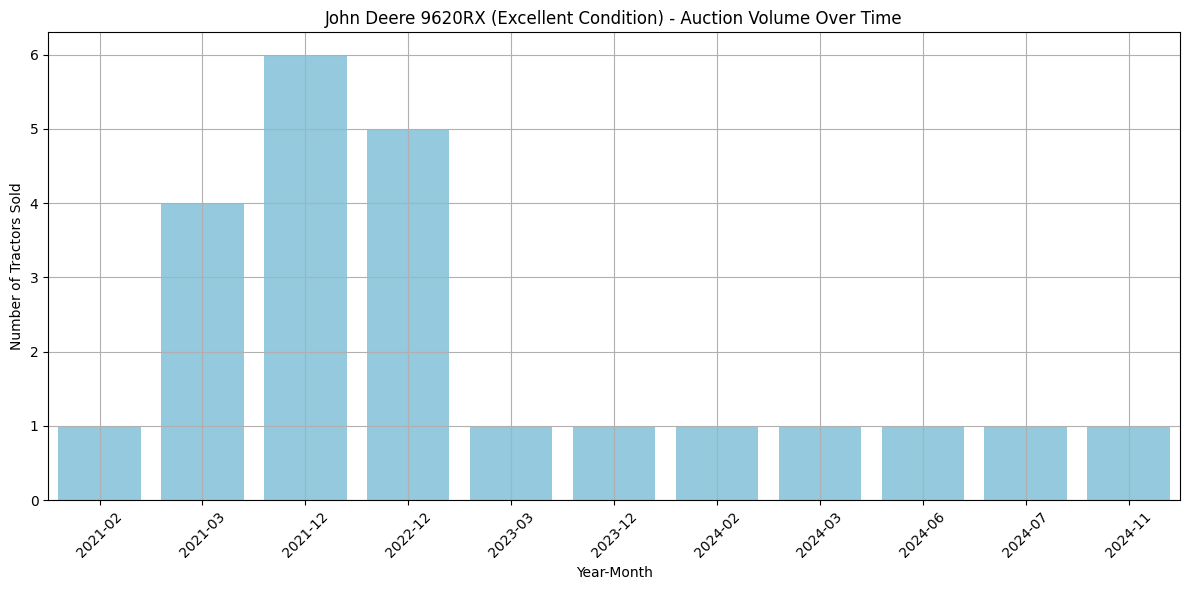

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the data
df_auction = pd.read_json('auc_tractors.json')

# Clean data
df_auction['price'] = pd.to_numeric(df_auction['price'].str.replace('[$,]', '', regex=True), errors='coerce')
df_auction['sold_date'] = pd.to_datetime(df_auction['sold_date'], errors='coerce')

# Filter data for John Deere 9620RX and Excellent condition
jd_9620rx_excellent = df_auction[
    (df_auction['name'].str.contains("John Deere 9620RX", case=False, na=False)) &
    (df_auction['condition'].str.lower() == 'excellent')
].copy()

# Drop rows with NaNs in key columns
jd_9620rx_excellent.dropna(subset=['price', 'sold_date'], inplace=True)

# Convert date to year-month
jd_9620rx_excellent['year_month'] = jd_9620rx_excellent['sold_date'].dt.to_period('M')

# Monthly aggregation
auction_monthly = jd_9620rx_excellent.groupby('year_month', dropna=True)['price'].agg(['mean', 'count']).reset_index()

# Convert Period to string for plotting
auction_monthly['year_month_str'] = auction_monthly['year_month'].astype(str)

# Plot Average Auction Price Over Time
plt.figure(figsize=(12,6))
sns.lineplot(data=auction_monthly, x='year_month_str', y='mean', marker='o')
plt.title('John Deere 9620RX (Excellent Condition) - Avg Auction Price Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Avg Auction Price (USD)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Auction Volume Over Time
plt.figure(figsize=(12,6))
sns.barplot(data=auction_monthly, x='year_month_str', y='count', color='skyblue')
plt.title('John Deere 9620RX (Excellent Condition) - Auction Volume Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Tractors Sold')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()
